# Experiment 1: Sensitivity to Controlled Error Counts

# generate_mutants

In [38]:
# generate_mutants.py
"""
Experiment 1 – Step 1 (controlled, sequential error addition)

Goal
────
For each gold SQL in BIRD-dev, apply atomic mutation operators sequentially,
with errors increasing by one new operator per depth. If an operator doesn't
apply at a given depth, we try another operator until we have exactly the
desired number of operators applied:

    depth 1 :  1 error
    depth 2 :  1 + 1 new error
    depth 3 :  1 + 1 new error + 1 more error
→ The goal is to track how adding more errors impacts EX/EXP/EXR.

Algorithm Overview
──────────────────
The mutation generation follows a depth-based sequential approach:

1. **Sequential Error Addition**: For each depth level (1, 2, 3), we build upon
   the previous level by adding exactly one more error. This creates a controlled
   progression where we can measure the cumulative impact of multiple errors.

2. **Operator Selection**: At each depth, we randomly select a new operator that:
   - Can be successfully applied to the current SQL
   - Doesn't conflict with previously applied operators
   - Actually modifies the AST (verified by attempting application)

3. **Conflict Avoidance**: Some operators are mutually incompatible (e.g.,
   projection_drop + add_irrelevant_column). The algorithm detects and avoids
   such conflicting combinations.

4. **Validation**: Each mutation sequence is validated to ensure:
   - All operators can be applied successfully
   - The final AST differs from the original
   - The resulting SQL is syntactically valid

Mutation Operators
──────────────────
We implement 7 atomic mutation operators that target different SQL components:

**SELECT Clause Mutations:**
• `projection_drop` — Removes a random column from SELECT list (requires >1 columns)
• `add_irrelevant_column` — Adds alias.* or bare * to SELECT list

**WHERE Clause Mutations:**
• `predicate_delete` — Removes a random predicate from WHERE clause (requires >1 predicates)
• `condition_flip` — Flips comparison operators (= ↔ !=, > ↔ <, >= ↔ <=, etc.)

**JOIN Mutations:**
• `join_break` — Removes ON condition from a random JOIN, breaking the join logic

**Aggregation Mutations:**
• `aggregation_swap` — Swaps aggregation functions (AVG↔SUM, MIN↔MAX, COUNT→SUM)

**ORDER BY Mutations:**
• `order_remove` — Completely removes ORDER BY clause

Operator Conflicts
──────────────────
Some operators are incompatible and shouldn't be applied together:
• `projection_drop` ↔ `add_irrelevant_column` (they can cancel each other out)

The conflict detection system prevents selecting operators that would neutralize
each other's effects, ensuring meaningful mutations at each depth level.

Correctness safeguards
──────────────────────
1.  **Each operator returns a boolean**
    • True  → it modified the AST.
    • False → it could not apply and the whole permutation is abandoned.

2.  **Final structural equality check**
    Even if every operator claims "changed", a later operator might UNDO
    the change (e.g., add * then drop it).
    We compare the fully-mutated AST with the original AST using
    `ast.equals(original_ast)`.
    If they are structurally identical, the sequence is discarded.

3.  **Conflict detection**
    Some operators conflict with each other (e.g., add_irrelevant_column
    vs projection_drop). We avoid selecting conflicting operators in the
    same sequence.

4.  **add_irrelevant_column** injects `alias.*` or bare `*`; we render
    SQL with `dialect="sqlite"` so sqlglot does not rewrite divisions
    into `NULLIF(x,0)`.

Output
──────
`data/evaluation/metrics/experiment_1/mutants.json`
with keys:
    question_id · db_id · depth · operators[] · mutated_sql · error_count · gold_sql
"""

from __future__ import annotations
import itertools, json, random
from pathlib import Path
from typing import Dict, List, Tuple, Set

import sqlglot
from sqlglot import parse_one, exp

# ────────────────────────────────────────────────────────────────────────
# Config – adjust paths for your workspace
# ────────────────────────────────────────────────────────────────────────
ROOT = Path("/Users/mhmalekpour/PycharmProjects/text-to-sql-coverage")

BIRD_DEV_JSON = ROOT / "data/benchmarks/Bird/bird_dev.json"
OUT_DIR       = ROOT / "data/evaluation/metrics/experiment_1"
OUT_FILE      = OUT_DIR / "mutants.json"
MAX_DEPTH     = 2  # Set this value to the desired max depth


# ────────────────────────────────────────────────────────────────────────
# Load BIRD-dev once
# ────────────────────────────────────────────────────────────────────────
def load_json(path: Path) -> list:
    with path.open() as f:
        return json.load(f)

BIRD_DEV = load_json(BIRD_DEV_JSON)


# ────────────────────────────────────────────────────────────────────────
# 1.  Atomic mutation operators (return True iff they change the AST)
# ────────────────────────────────────────────────────────────────────────
SqlAst = exp.Expression
def _rc(seq): return random.choice(seq) if seq else None


def projection_drop(ast: SqlAst) -> bool:
    """
    Remove a random column from the SELECT list.
    Requires at least 2 columns to avoid creating invalid SQL.
    """
    sel = ast.find(exp.Select)
    if sel and len(sel.expressions) > 1:
        sel.expressions.remove(_rc(sel.expressions))
        return True
    return False


def predicate_delete(ast: SqlAst) -> bool:
    """
    Remove a random predicate from the WHERE clause.
    Handles compound conditions (AND/OR) by flattening and reconstructing.
    Requires at least 2 predicates to avoid removing the entire WHERE clause.
    """
    where = ast.args.get("where")
    if not where:
        return False

    def flat(node):
        if isinstance(node, (exp.And, exp.Or)):
            return flat(node.left) + flat(node.right)
        return [node]

    preds = flat(where.this)
    if len(preds) <= 1:
        return False

    preds.remove(_rc(preds))
    new_w = preds[0]
    for p in preds[1:]:
        new_w = exp.and_(new_w, p)
    ast.set("where", exp.Where(this=new_w))
    return True


def join_break(ast: SqlAst) -> bool:
    """
    Remove the ON condition from a random JOIN clause.
    This breaks the join logic, often resulting in a cartesian product.
    Only targets JOINs that have an ON condition.
    """
    joins = [j for j in ast.find_all(exp.Join) if j.args.get("on")]
    j = _rc(joins)
    if j:
        j.set("on", None)
        return True
    return False


_AGG_SWAP = dict(avg="sum", sum="avg", min="max", max="min", count="sum")
def aggregation_swap(ast: SqlAst) -> bool:
    """
    Swap aggregation functions with semantically different ones.
    - AVG ↔ SUM (changes from mean to total)
    - MIN ↔ MAX (changes from smallest to largest)
    - COUNT → SUM (changes from count to sum, often meaningless)
    """
    aggs = [f for f in ast.find_all(exp.Func) if f.name.lower() in _AGG_SWAP]
    f = _rc(aggs)
    if f:
        f.set("name", _AGG_SWAP[f.name.lower()])
        return True
    return False


def order_remove(ast: SqlAst) -> bool:
    """
    Completely remove the ORDER BY clause.
    This can change result ordering in cases where it matters for correctness.
    """
    if ast.args.get("order"):
        ast.set("order", None)
        return True
    return False


def add_irrelevant_column(ast: SqlAst) -> bool:
    """
    Inject alias.* or bare * into the SELECT list.
    This adds extra columns that weren't in the original query.
    Skip if a star is already present to avoid redundancy.
    Prioritizes table alias if available, falls back to table name or bare *.
    """
    sel = ast.find(exp.Select)
    if not sel:
        return False
    if any(isinstance(e, exp.Star) for e in sel.expressions):
        return False

    first_tbl = next(ast.find_all(exp.Table), None)
    if first_tbl and first_tbl.alias:
        star = exp.Star(this=exp.Identifier(this=first_tbl.alias))
    elif first_tbl:
        star = exp.Star(this=first_tbl.this.copy())
    else:
        star = exp.Star()
    sel.expressions.append(star)
    return True


def condition_flip(ast: SqlAst) -> bool:
    """
    Flip comparison operators to their logical opposites.
    This fundamentally changes the meaning of conditions:
    - = becomes != (equal becomes not equal)
    - > becomes < (greater becomes less)
    - >= becomes <= (greater-or-equal becomes less-or-equal)
    This is a good alternative when projection operators conflict.
    """
    flip_map = {
        exp.EQ: exp.NEQ,
        exp.NEQ: exp.EQ,
        exp.GT: exp.LT,
        exp.LT: exp.GT,
        exp.GTE: exp.LTE,
        exp.LTE: exp.GTE,
    }

    comparisons = [node for node in ast.find_all(*flip_map.keys())]
    comp = _rc(comparisons)
    if comp:
        new_type = flip_map[type(comp)]
        comp.replace(new_type(this=comp.this, expression=comp.expression))
        return True
    return False


# Registry of all available mutation operators
OPERATORS: Dict[str, callable] = {
    "projection_drop": projection_drop,
    "predicate_delete": predicate_delete,
    "join_break":      join_break,
    "aggregation_swap": aggregation_swap,
    "order_remove":     order_remove,
    "add_irrelevant_column": add_irrelevant_column,
    "condition_flip": condition_flip,
}
OP_NAMES = tuple(OPERATORS.keys())


# ────────────────────────────────────────────────────────────────────────
# 2.  Define operator conflicts (operators that shouldn't be used together)
# ────────────────────────────────────────────────────────────────────────
OPERATOR_CONFLICTS: Dict[str, Set[str]] = {
    "projection_drop": {"projection_drop", "add_irrelevant_column"},
    "add_irrelevant_column": { "add_irrelevant_column", "projection_drop"},
    "condition_flip" : {"condition_flip"},
    "order_remove": {"order_remove"},
    "join_break": {"join_break"},
    # Add more conflicts as needed, e.g.:
    # "predicate_delete": {"some_other_predicate_op"},
}


def has_conflict(op: str, existing_ops: List[str]) -> bool:
    """
    Check if adding this operator would conflict with existing ones.
    Returns True if the operator conflicts with any already selected operator.
    """
    conflicts = OPERATOR_CONFLICTS.get(op, set())
    return any(existing_op in conflicts for existing_op in existing_ops)


# ────────────────────────────────────────────────────────────────────────
# 3.  Apply a sequence; discard if any op is a no-op or net-no-change
# ────────────────────────────────────────────────────────────────────────
def apply_sequence(sql: str, seq: Tuple[str, ...]) -> str | None:
    """
    Apply operators in the given order.
    Returns mutated SQL (dialect='sqlite') or None if:
      • any operator could not be applied, OR
      • final AST is structurally equal to the original AST.
    """
    original_ast = parse_one(sql, read="sqlite")
    ast = original_ast.copy()

    for op in seq:
        if not OPERATORS[op](ast):          # operator had no effect
            return None

    if ast == original_ast:                 # nothing changed overall
        return None

    return ast.sql(dialect="sqlite")


# ────────────────────────────────────────────────────────────────────────
# 4.  Generate mutants with sequential error addition (depth-based)
# ────────────────────────────────────────────────────────────────────────
def generate_mutation_suite(
    depths: Tuple[int, ...] = (1, 2, 3),
    seed: int = 42,
) -> List[dict]:
    """
    Generate mutation suite with sequential error addition.

    For each SQL query and each depth level:
    1. Start with an empty operator sequence
    2. For each error level (1 to depth):
       - Filter out operators that conflict with already selected ones
       - Try random operators until one successfully applies
       - Add the working operator to the sequence
    3. Save the mutant if we successfully applied the target number of operators

    Args:
        depths: Tuple of depth levels to generate (currently unused, uses MAX_DEPTH)
        seed: Random seed for reproducible results

    Returns:
        List of mutant dictionaries with metadata and mutated SQL
    """
    random.seed(seed)
    mutants: List[dict] = []

    for item in BIRD_DEV:
        sql, qid, db = item["SQL"], item["question_id"], item["db_id"]

        for depth in range(1, MAX_DEPTH + 1):  # Generate mutants up to MAX_DEPTH
            # Start with one error and sequentially add new errors per depth
            operator_sequence = []
            for base_error in range(depth):
                operators_left = list(OPERATORS.keys())
                # Filter out operators that conflict with already selected ones
                operators_left = [op for op in operators_left
                                if not has_conflict(op, operator_sequence)]

                # Start with one random operator for each level
                while operators_left:
                    op = random.choice(operators_left)
                    new_ast = apply_sequence(sql, operator_sequence + [op])
                    if new_ast is not None:
                        operator_sequence.append(op)
                        break
                    else:
                        operators_left.remove(op)  # remove non-working operator

                if len(operator_sequence) != base_error + 1:
                    # If we cannot apply enough operators, skip this path
                    break

            # If the mutation was valid for this depth, save it
            if len(operator_sequence) == depth:
                final_mutated_sql = apply_sequence(sql, operator_sequence)
                if final_mutated_sql:  # Double-check the sequence still works
                    mutants.append(
                        {
                            "question_id": qid,
                            "db_id": db,
                            "depth": depth,
                            "operators": operator_sequence,
                            "mutated_sql": final_mutated_sql,
                            "error_count": depth,
                            "gold_sql": sql,
                        }
                    )

    return mutants


# ────────────────────────────────────────────────────────────────────────
# 5.  Entry-point – build and save mutants.json
# ────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Generating mutants with sequential error addition …")
    suite = generate_mutation_suite()
    print(f"Generated {len(suite):,} mutants")

    OUT_DIR.mkdir(parents=True, exist_ok=True)
    with OUT_FILE.open("w") as f:
        json.dump(suite, f, indent=2)
    print(f"Mutants written to {OUT_FILE}")


Generating mutants with sequential error addition …
Generated 4,942 mutants
Mutants written to /Users/mhmalekpour/PycharmProjects/text-to-sql-coverage/data/evaluation/metrics/experiment_1/mutants.json


-------


# evaluator version 1

In [ ]:
# evaluate_mutants.py
"""
Experiment 1 – Step 2 (parallel evaluation with multiple techniques)

Goal
────
• Loads mutants.json produced in Step 1.
• Evaluates each mutant using multiple evaluation techniques in parallel
• Each technique produces its own separate results file
• Extracts metrics EX / EXP / EXR / F1 and latency from Evaluation's return value

Process
───────
1. Load mutants from Step 1
2. Apply smart sampling (by complete question_id groups) and quality filtering
3. For each evaluation technique:
   - Create a separate evaluation run with technique-specific logging
   - Use adaptive worker count (1 for API-heavy techniques, more for others)
   - Use ThreadPoolExecutor with subprocess isolation (≤ 30s per query)
   - Generate technique-specific output file
4. Each mutant is evaluated inside its own short-lived subprocess with timeout
5. Results are saved as separate JSON files per technique

Sampling Strategy
─────────────────
• When SAMPLE_SIZE is set, we sample complete question_id groups (not individual mutants)
• This ensures all depth levels (1, 2, 3) for each original query are included together
• Quality filtering removes question_id groups where any mutant achieves EX=1
  (suggests problematic queries where errors don't affect results)

Worker Management
─────────────────
• API-heavy techniques (with embedding calls) use 1 worker to avoid rate limits
• Non-API techniques can use multiple workers for faster processing
• FORCE_SEQUENTIAL mode available to run everything with 1 worker

Logging
───────
• Each evaluation technique gets its own log directory (logs_{technique_name})
• Logs are saved alongside the mutant scores files for easy organization
• LOG flag can be toggled to enable/disable detailed evaluation logging

Performance
───────────
• Uses ThreadPoolExecutor with adaptive worker count per technique
• Each query evaluation is isolated in subprocess with SIGALRM timeout
• Guaranteed ≤ 30 seconds per individual query evaluation

Output Files
────────────
• mutant_scores_exact_column_and_exact_cell.json
• mutant_scores_unified_column_and_semantic_row.json
• logs_exact_column_and_exact_cell/ (if LOG=True)
• logs_unified_column_and_semantic_row/ (if LOG=True)
• (Additional files based on EVALUATION_TECHNIQUES list)

Configuration
─────────────
Edit SAMPLE_SIZE to a small integer for smoke-testing, or set it to
None to score the entire dataset. Set LOG to True/False to control logging.
Set FORCE_SEQUENTIAL to True to use 1 worker for all techniques.
"""

from __future__ import annotations
import json, copy, os, signal, time, random
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from typing import List, Dict
from collections import defaultdict

import multiprocessing as mp
from tqdm import tqdm

from src.evaluation import Evaluation, EvaluationTechnique
from src.core.database.database_handler import DBMS
from src.core.model_manager import OpenAIModel

# ──────────────────────────────────────────────────────────────────────────
# 0.  Paths, constants, and evaluation techniques
# ──────────────────────────────────────────────────────────────────────────
ROOT = Path("/Users/mhmalekpour/PycharmProjects/text-to-sql-coverage")

MUTANTS_JSON = ROOT / "data/evaluation/metrics/experiment_1/mutants.json"
OUT_DIR = ROOT / "data/evaluation/metrics/experiment_1"
DEV_DB_ROOT = ROOT / "data/benchmarks/Bird/dev_databases"

# Multiple evaluation techniques to compare mutation impact across different metrics
EVALUATION_TECHNIQUES = [
    EvaluationTechnique.EXACT_COLUMN_AND_EXACT_CELL,
    EvaluationTechnique.SEMANTIC_COLUMN_AND_EXACT_CELL,
    EvaluationTechnique.UNIFIED_COLUMN_AND_SEMANTIC_ROW
]

# Embedding model configuration for semantic evaluation techniques
EMBEDDING_MODEL = OpenAIModel.TEXT_EMBEDDING_3_SMALL

# Configuration options
SAMPLE_SIZE = 120  # None → score all mutants; small int for quick test (applied to question groups)
PER_QUERY_TIMEOUT = 60  # wall-clock seconds per individual query evaluation
LOG = True  # Enable/disable detailed evaluation logging per technique
FORCE_SEQUENTIAL = False  # Set to True to use 1 worker for all techniques (safest option)

# Techniques that use embedding API calls and should use fewer workers
API_HEAVY_TECHNIQUES = {
    EvaluationTechnique.SEMANTIC_COLUMN_AND_EXACT_CELL,
    EvaluationTechnique.UNIFIED_COLUMN_AND_SEMANTIC_ROW,
    EvaluationTechnique.SEMANTIC_COLUMN_AND_SEMANTIC_ROW,  # If you add this later
}


# ──────────────────────────────────────────────────────────────────────────
# 1.  Smart sampling and quality filtering functions
# ──────────────────────────────────────────────────────────────────────────
def group_mutants_by_question(mutants: List[Dict]) -> Dict[str, List[Dict]]:
    """
    Group mutants by question_id to ensure complete sets are processed together.

    Args:
        mutants: List of mutant dictionaries

    Returns:
        Dictionary mapping question_id to list of mutants for that question
    """
    groups = defaultdict(list)
    for mutant in mutants:
        question_id = mutant["question_id"]
        groups[question_id].append(mutant)

    return dict(groups)


def smart_sample_mutants(mutants: List[Dict], sample_size: int = None) -> List[Dict]:
    """
    Apply smart sampling that maintains complete question_id groups.

    When SAMPLE_SIZE is specified, we sample complete question groups rather than
    individual mutants. This ensures all depth levels (1, 2, 3) for each original
    query are included together for meaningful analysis.

    Args:
        mutants: List of all mutants
        sample_size: Target number of mutants (approximate, since we keep complete groups)

    Returns:
        List of sampled mutants maintaining complete question groups
    """
    if sample_size is None:
        return mutants

    # Group by question_id
    question_groups = group_mutants_by_question(mutants)

    print(f"Original: {len(mutants)} mutants across {len(question_groups)} questions")

    # Calculate how many question groups to sample
    avg_mutants_per_question = len(mutants) / len(question_groups)
    target_questions = max(1, int(sample_size / avg_mutants_per_question))
    target_questions = min(target_questions, len(question_groups))

    # Randomly sample question groups
    random.seed(42)  # For reproducible sampling
    sampled_question_ids = random.sample(list(question_groups.keys()), target_questions)

    # Collect all mutants from sampled questions
    sampled_mutants = []
    for question_id in sampled_question_ids:
        sampled_mutants.extend(question_groups[question_id])

    print(f"Sampled: {len(sampled_mutants)} mutants across {target_questions} questions")
    print(f"Average mutants per question: {avg_mutants_per_question:.1f}")

    return sampled_mutants


def filter_problematic_questions(mutants: List[Dict]) -> List[Dict]:
    """
    Remove question groups where any mutant achieves EX=1.

    If a mutant has EX=1 (perfect execution match), it suggests there's a problem
    with the query (like generating null tables) where adding errors doesn't affect
    the result. We remove the entire question group in such cases.

    Args:
        mutants: List of evaluated mutants (must have EX field)

    Returns:
        Filtered list of mutants with problematic questions removed
    """
    # Group by question_id and check for EX=1
    question_groups = group_mutants_by_question(mutants)
    problematic_questions = set()

    for question_id, group_mutants in question_groups.items():
        for mutant in group_mutants:
            if mutant.get("EX") == 1:
                problematic_questions.add(question_id)
                break

    # Filter out problematic question groups
    filtered_mutants = []
    for mutant in mutants:
        if mutant["question_id"] not in problematic_questions:
            filtered_mutants.append(mutant)

    if problematic_questions:
        removed_count = len(mutants) - len(filtered_mutants)
        print(f"  → Quality filter: Removed {len(problematic_questions)} problematic questions "
              f"({removed_count} mutants) with EX=1")
        print(f"  → Remaining: {len(filtered_mutants)} mutants across "
              f"{len(set(m['question_id'] for m in filtered_mutants))} questions")

    return filtered_mutants


# ──────────────────────────────────────────────────────────────────────────
# 2.  Worker count management for different technique types
# ──────────────────────────────────────────────────────────────────────────
def get_optimal_worker_count(technique: EvaluationTechnique) -> int:
    """
    Determine optimal worker count based on technique type.

    API-heavy techniques (with embedding calls) should use 1 worker to avoid:
    - Rate limiting from the API provider
    - Connection timeouts from concurrent requests
    - API quota exhaustion

    Non-API techniques can safely use multiple workers.

    Args:
        technique: The evaluation technique to analyze

    Returns:
        Optimal number of workers for this technique
    """
    if FORCE_SEQUENTIAL:
        return 1

    if technique in API_HEAVY_TECHNIQUES:
        return 1  # Sequential processing for API-heavy techniques
    else:
        # Non-API techniques can use multiple workers
        return min(4, max(1, os.cpu_count() // 2))


# ──────────────────────────────────────────────────────────────────────────
# 3.  Subprocess worker – evaluates one mutant with SIGALRM timeout
# ──────────────────────────────────────────────────────────────────────────
def _worker(cfg: dict, pred_sql: str, gold_sql: str, q: mp.Queue):
    """
    Executes Evaluation.run_evaluation with a configurable timeout alarm.

    This function runs in an isolated subprocess to prevent hanging
    evaluations from blocking the entire pipeline. Uses SIGALRM for
    strict timeout enforcement.

    Args:
        cfg: Evaluation configuration dictionary
        pred_sql: Mutated SQL to evaluate
        gold_sql: Ground truth SQL for comparison
        q: Multiprocessing queue for result communication

    Queue Output:
        (metrics_dict, latency) on success
        (None, -1) on error or timeout
    """

    def _timeout(_s, _f):
        raise TimeoutError("Evaluation timeout exceeded")

    signal.signal(signal.SIGALRM, _timeout)
    signal.alarm(PER_QUERY_TIMEOUT)

    start = time.time()
    try:
        ctx = Evaluation(cfg).run_evaluation(
            predicted_sql=pred_sql,
            ground_truth_sql=gold_sql,
            log=LOG,  # Use configurable LOG flag
        )
        latency = ctx.get("latency", time.time() - start)
        q.put((ctx["metrics"], latency))
    except Exception as e:
        # For debugging: could log the exception type/message
        # print(f"Worker evaluation failed: {type(e).__name__}: {e}")
        q.put((None, -1))
    finally:
        signal.alarm(0)  # cancel alarm to prevent signal leakage


def score_one_mutant(mutant: dict, template_cfg: dict) -> dict:
    """
    Wrapper executed by the thread pool for each mutant evaluation.

    Process:
    1. Creates subprocess-specific config with correct database path
    2. Spawns isolated subprocess for evaluation with timeout
    3. Enforces wall-clock timeout and handles subprocess cleanup
    4. Merges evaluation metrics back into mutant dictionary

    Args:
        mutant: Mutant dictionary containing SQL and metadata
        template_cfg: Base evaluation configuration to copy

    Returns:
        Updated mutant dict with EX/EXP/EXR/F1/latency fields
    """
    # Create subprocess-specific config with correct database path
    cfg = copy.deepcopy(template_cfg)
    db_file = DEV_DB_ROOT / mutant["db_id"] / f"{mutant['db_id']}.sqlite"
    cfg["db_params"]["db_path"] = str(db_file)

    # Spawn subprocess with timeout enforcement
    q = mp.Queue(1)
    p = mp.Process(target=_worker,
                   args=(cfg, mutant["mutated_sql"], mutant["gold_sql"], q))
    p.start()
    p.join(PER_QUERY_TIMEOUT)

    # Handle subprocess cleanup and timeout
    if p.is_alive():
        p.terminate()
        p.join()

    # Extract results from subprocess
    try:
        metrics, latency = q.get_nowait()
    except Exception:
        metrics, latency = None, -1

    # Merge evaluation results into mutant dictionary
    if not metrics:
        mutant.update({"EX": None, "EXP": None, "EXR": None, "F1": None, "latency": latency})
    else:
        mutant.update(
            {
                "EX": metrics.get("EX", 0),
                "EXP": metrics.get("EXP", 0.0),
                "EXR": metrics.get("EXR", 0.0),
                "F1": metrics.get("F1", 0.0),
                "latency": latency,
            }
        )
    return mutant


def get_technique_name(technique: EvaluationTechnique) -> str:
    """
    Convert evaluation technique enum to filename-safe string.

    Args:
        technique: EvaluationTechnique enum value

    Returns:
        Lowercase string suitable for filename
    """
    return technique.name.lower()


def create_technique_log_dir(technique_name: str) -> str:
    """
    Create and return the log directory path for a specific technique.

    Creates a logs_{technique_name} directory alongside the output files.

    Args:
        technique_name: Technique name (from get_technique_name)

    Returns:
        String path to the technique-specific log directory
    """
    log_dir = OUT_DIR / f"logs_{technique_name}"
    log_dir.mkdir(parents=True, exist_ok=True)
    return str(log_dir)


def evaluate_with_technique(mutants: List[Dict], technique: EvaluationTechnique) -> List[Dict]:
    """
    Evaluate all mutants using a specific evaluation technique.

    Uses adaptive worker count: 1 for API-heavy techniques, more for others.

    Args:
        mutants: List of mutant dictionaries to evaluate
        technique: Evaluation technique to use

    Returns:
        List of mutants with evaluation results added (filtered for quality)
    """
    technique_name = get_technique_name(technique)

    # Create technique-specific log directory
    log_dir_path = create_technique_log_dir(technique_name)

    # Determine optimal worker count for this technique
    max_workers = get_optimal_worker_count(technique)
    is_api_heavy = technique in API_HEAVY_TECHNIQUES

    # Create evaluation configuration template for this technique
    eval_template = {
        "evaluation_technique": technique,
        "db_params": {"dbms": DBMS.SQLITE, "db_path": ""},  # db_path filled per query
        "embedding_model": EMBEDDING_MODEL,
        "logs_dir_path": log_dir_path,  # Technique-specific log directory
    }

    print(f"  → Evaluating {len(mutants):,} mutants with {technique.name}")
    print(f"  → Workers: {max_workers} {'(sequential for API safety)' if is_api_heavy else '(parallel)'}")
    if LOG:
        print(f"  → Logs: {log_dir_path}")

    scored: List[dict] = []
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        # Submit all evaluation tasks
        futures = [pool.submit(score_one_mutant, copy.deepcopy(m), eval_template)
                   for m in mutants]

        # Collect results with progress tracking
        for future in tqdm(as_completed(futures),
                           total=len(futures),
                           desc=f"  {technique_name}",
                           ncols=80):
            scored.append(future.result())

    # Apply quality filtering after evaluation
    filtered_scored = filter_problematic_questions(scored)

    return filtered_scored


# ──────────────────────────────────────────────────────────────────────────
# 4.  Main evaluation routine
# ──────────────────────────────────────────────────────────────────────────
def main():
    """
    Main evaluation pipeline that processes mutants with multiple techniques.

    Process:
    1. Load mutants from Step 1
    2. Apply smart sampling (by question groups) and quality filtering
    3. For each evaluation technique:
       - Determine optimal worker count (1 for API-heavy, more for others)
       - Create technique-specific log directory
       - Run complete evaluation suite with logging
       - Apply quality filtering (remove questions with EX=1)
       - Save technique-specific results
    4. Generate summary statistics
    """
    print("=" * 60)
    print("MUTANT EVALUATION - Multiple Techniques")
    print("=" * 60)

    # Load mutants from Step 1
    print(f"Loading mutants from {MUTANTS_JSON}")
    with MUTANTS_JSON.open() as f:
        all_mutants: List[Dict] = json.load(f)

    print(f"Loaded {len(all_mutants):,} total mutants")

    # Apply smart sampling that maintains complete question groups
    sampled_mutants = smart_sample_mutants(all_mutants, SAMPLE_SIZE)

    # Set multiprocessing method for subprocess safety
    mp.set_start_method("fork", force=True)  # safe for macOS / Jupyter

    # Display configuration
    print(f"Configuration:")
    print(f"  Embedding model: {EMBEDDING_MODEL.value}")
    print(f"  Per-query timeout: {PER_QUERY_TIMEOUT}s")
    print(f"  Logging enabled: {LOG}")
    print(f"  Force sequential: {FORCE_SEQUENTIAL}")
    print(f"  Output directory: {OUT_DIR}")

    # Show worker strategy
    print(f"\nWorker Strategy:")
    for technique in EVALUATION_TECHNIQUES:
        workers = get_optimal_worker_count(technique)
        is_api = technique in API_HEAVY_TECHNIQUES
        print(f"  {technique.name}: {workers} worker{'s' if workers > 1 else ''} "
              f"{'(API-heavy)' if is_api else '(standard)'}")

    # Evaluate with each technique and save separate results
    print(f"\nEvaluating with {len(EVALUATION_TECHNIQUES)} different techniques:")

    for i, technique in enumerate(EVALUATION_TECHNIQUES, 1):
        technique_name = get_technique_name(technique)
        print(f"\n[{i}/{len(EVALUATION_TECHNIQUES)}] {technique.name}")

        # Run evaluation for this technique (includes quality filtering)
        scored_mutants = evaluate_with_technique(sampled_mutants, technique)

        # Save technique-specific results
        out_file = OUT_DIR / f"mutant_scores_{technique_name}.json"
        out_file.parent.mkdir(parents=True, exist_ok=True)

        with out_file.open("w") as f:
            json.dump(scored_mutants, f, indent=2)

        # Calculate summary statistics
        successful_evals = [m for m in scored_mutants if m.get("EX") is not None]
        failed_evals = len(scored_mutants) - len(successful_evals)

        if successful_evals:
            avg_ex = sum(m["EX"] for m in successful_evals) / len(successful_evals)
            avg_f1 = sum(m["F1"] for m in successful_evals) / len(successful_evals)
            avg_latency = sum(m["latency"] for m in successful_evals) / len(successful_evals)

            # Calculate depth distribution
            depth_counts = {}
            for m in successful_evals:
                depth = m.get("depth", "unknown")
                depth_counts[depth] = depth_counts.get(depth, 0) + 1

            print(f"  → Results saved to {out_file.name}")
            print(f"  → Final dataset: {len(scored_mutants)} mutants across "
                  f"{len(set(m['question_id'] for m in scored_mutants))} questions")
            print(f"  → Success rate: {len(successful_evals)}/{len(scored_mutants)} "
                  f"({100 * len(successful_evals) / len(scored_mutants):.1f}%)")
            if failed_evals > 0:
                print(f"  → Failed evaluations: {failed_evals}")
            print(f"  → Depth distribution: {dict(sorted(depth_counts.items()))}")
            print(f"  → Average EX: {avg_ex:.3f}")
            print(f"  → Average F1: {avg_f1:.3f}")
            print(f"  → Average latency: {avg_latency:.2f}s")
        else:
            print(f"  → WARNING: All evaluations failed for {technique.name}")
            print(f"  → Results saved to {out_file.name}")

    print(f"\n{'=' * 60}")
    print("EVALUATION COMPLETE")
    print(f"Results saved in: {OUT_DIR}")
    if LOG:
        print(f"Logs saved in technique-specific subdirectories of: {OUT_DIR}")
    print(f"{'=' * 60}")


# ──────────────────────────────────────────────────────────────────────────
# Entry-point
# ──────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    main()


# REPORT

Experiment 1 - Multi-Technique Sensitivity Analysis
Found 2 technique(s):
  • Exact Column And Exact Cell (exact_column_and_exact_cell)
  • Semantic Column And Exact Cell (semantic_column_and_exact_cell)

Processing Exact Column And Exact Cell...
  Mean scores by #errors:
                  EX    EXP    EXR     F1
error_count                            
1            0.044  0.381  0.456  0.344
2            0.008  0.121  0.250  0.071
3            0.000  0.049  0.221  0.032
  Data diagnostics:
    Total records: 400
    Error counts: [np.int64(1), np.int64(2), np.int64(3)]
    EX: 369 non-null, 2 unique values
    EXP: 369 non-null, 62 unique values
    EXR: 369 non-null, 12 unique values
    F1: 369 non-null, 69 unique values

Processing Semantic Column And Exact Cell...
  Mean scores by #errors:
                  EX    EXP    EXR     F1
error_count                            
1            0.066  0.180  0.364  0.138
2            0.014  0.086  0.240  0.041
3            0.000  0.002  0.208 

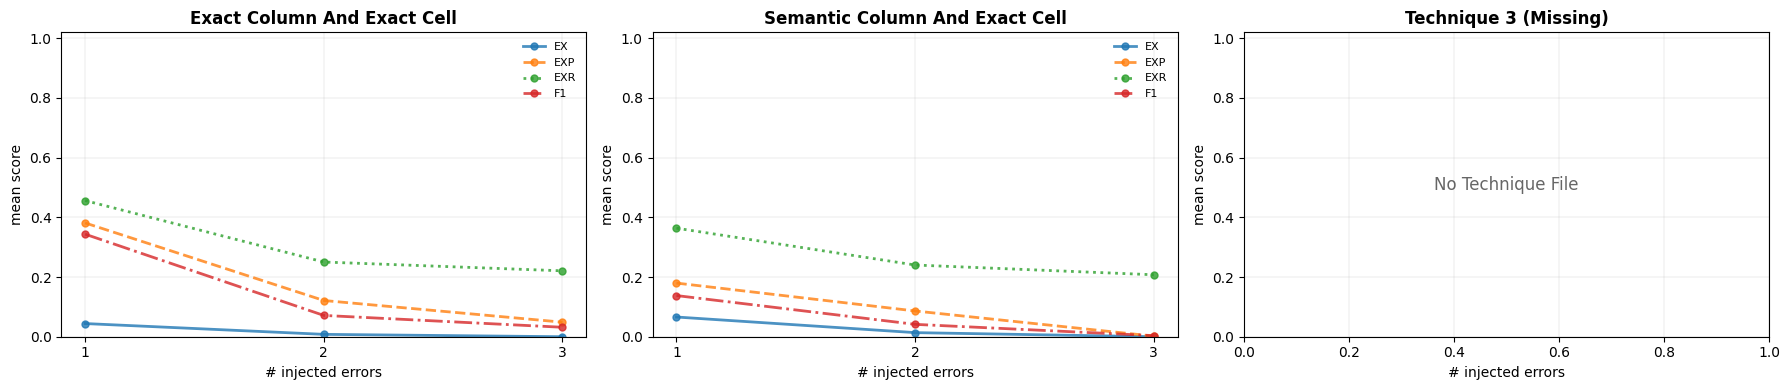


[✓] Figure saved → /Users/mhmalekpour/PycharmProjects/text-to-sql-coverage/data/evaluation/metrics/experiment_1/figure1_mean_vs_errors_multi_technique.png
[✓] Correlations table saved → /Users/mhmalekpour/PycharmProjects/text-to-sql-coverage/data/evaluation/metrics/experiment_1/table1_correlations_multi_technique.csv

Correlation Summary:

Exact Column And Exact Cell:
metric spearman_rho kendall_tau
    EX       -0.136      -0.128
   EXP       -0.275      -0.241
   EXR       -0.217      -0.197
    F1       -0.278      -0.243

Semantic Column And Exact Cell:
metric spearman_rho kendall_tau
    EX       -0.159      -0.150
   EXP       -0.190      -0.164
   EXR       -0.139      -0.125
    F1       -0.169      -0.146


In [47]:
# report.py
"""
Experiment 1 – Sensitivity to Controlled Error Counts (Multi-Technique Analysis)
─────────────────────────────────────────────────────────────────────────────────
This script reads all mutant_scores_*.json files (one per evaluation technique) and produces:

1. **Figure 1** – mean score vs. #injected errors (EX, EXP, EXR, F1) for each technique.
   • Three plots in one row, one per technique
   • Distinct colours / linestyles, slight transparency.
   • X-axis shows *only integer ticks* (1, 2, 3 …).
   • If a technique file doesn't exist, shows empty plot with "No Data" message

2. **Table 1** – Spearman ρ and Kendall τ correlations between
   error_count and each metric for each technique.
   • Rows with NaNs in a metric are ignored (nan_policy="omit").
   • If fewer than two valid points remain (or all values equal),
     the correlation is reported as NaN.

Artefacts are saved next to the scores files.
"""

from pathlib import Path
import json
import glob
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator  # integer x-ticks
from scipy.stats import spearmanr, kendalltau

# ────────────────────────────────────────────────────────────────────────
# 0.  File paths – adjust to your environment
# ────────────────────────────────────────────────────────────────────────
ROOT = Path("/Users/mhmalekpour/PycharmProjects/text-to-sql-coverage")

SCORES_DIR = ROOT / "data/evaluation/metrics/experiment_1"
FIGURE_PATH = ROOT / "data/evaluation/metrics/experiment_1/figure1_mean_vs_errors_multi_technique.png"
TABLE_PATH = ROOT / "data/evaluation/metrics/experiment_1/table1_correlations_multi_technique.csv"


# ────────────────────────────────────────────────────────────────────────
# 1.  Find all mutant score files and extract technique names
# ────────────────────────────────────────────────────────────────────────
def find_mutant_score_files():
    """Find all mutant_scores_*.json files and extract technique names."""
    pattern = str(SCORES_DIR / "mutant_scores_*.json")
    files = glob.glob(pattern)

    techniques = []
    for file_path in files:
        filename = Path(file_path).name
        # Extract technique name from filename: mutant_scores_{technique}.json
        technique_name = filename.replace("mutant_scores_", "").replace(".json", "")
        techniques.append({
            "name": technique_name,
            "path": Path(file_path),
            "display_name": technique_name.replace("_", " ").title()
        })

    return sorted(techniques, key=lambda x: x["name"])


# ────────────────────────────────────────────────────────────────────────
# 2.  Load and process data for a single technique
# ────────────────────────────────────────────────────────────────────────
def load_technique_data(file_path):
    """Load and process mutant scores for a single technique."""
    try:
        with file_path.open() as f:
            records = json.load(f)

        df = pd.DataFrame(records)
        required_cols = {"error_count", "EX", "EXP", "EXR", "F1"}
        missing = required_cols.difference(df.columns)

        if missing:
            print(f"[!] Warning: {file_path.name} missing columns: {missing}")
            return None

        return df
    except Exception as e:
        print(f"[!] Error loading {file_path.name}: {e}")
        return None


# ────────────────────────────────────────────────────────────────────────
# 3.  Plot mean scores for a single technique
# ────────────────────────────────────────────────────────────────────────
def plot_technique_scores(ax, df, technique_name):
    """Plot mean scores vs error count for a single technique."""
    if df is None or df.empty:
        ax.text(0.5, 0.5, "No Data Available",
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, fontsize=12, alpha=0.6)
        ax.set_title(technique_name, fontsize=12, fontweight='bold')
        ax.set_xlabel("# injected errors")
        ax.set_ylabel("mean score")
        ax.set_ylim(0, 1.02)
        ax.grid(True, linewidth=0.3, alpha=0.6)
        return

    # Calculate mean scores per error count
    mean_tbl = (
        df.groupby("error_count")[["EX", "EXP", "EXR", "F1"]]
        .mean()
        .sort_index()
    )

    metrics = ["EX", "EXP", "EXR", "F1"]
    linestyles = ["-", "--", ":", "-."]
    colours = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, m in enumerate(metrics):
        ax.plot(
            mean_tbl.index,
            mean_tbl[m],
            label=m,
            linestyle=linestyles[i],
            color=colours[i],
            linewidth=2,
            alpha=0.8,
            marker="o",
            markersize=5,
        )

    ax.set_title(technique_name, fontsize=12, fontweight='bold')
    ax.set_xlabel("# injected errors")
    ax.set_ylabel("mean score")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # integer ticks only
    ax.set_ylim(0, 1.02)
    ax.grid(True, linewidth=0.3, alpha=0.6)
    ax.legend(frameon=False, loc="upper right", fontsize=8)


# ────────────────────────────────────────────────────────────────────────
# 4.  Calculate correlations for a single technique with robust error handling
# ────────────────────────────────────────────────────────────────────────
def is_correlation_computable(x, y):
    """
    Check if correlation can be meaningfully computed between x and y.

    Returns False if:
    - Less than 2 valid (non-NaN) pairs
    - Either variable has zero variance (all values the same)
    - All values are NaN
    """
    # Create mask for valid (non-NaN) pairs
    valid_mask = ~(pd.isna(x) | pd.isna(y))

    if valid_mask.sum() < 2:
        return False, "Insufficient valid data points"

    x_valid = x[valid_mask]
    y_valid = y[valid_mask]

    # Check for zero variance (all values the same)
    if len(np.unique(x_valid)) < 2:
        return False, "X variable has zero variance"

    if len(np.unique(y_valid)) < 2:
        return False, "Y variable has zero variance"

    return True, "OK"


def safe_correlation(x, y, method='spearman'):
    """
    Safely calculate correlation with proper validation and warning suppression.

    Args:
        x, y: pandas Series or arrays to correlate
        method: 'spearman' or 'kendall'

    Returns:
        correlation coefficient (float or NaN if can't compute)
    """
    can_compute, reason = is_correlation_computable(x, y)

    if not can_compute:
        return np.nan

    try:
        # Suppress scipy warnings for correlation edge cases
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)

            if method == 'spearman':
                corr, _ = spearmanr(x, y, nan_policy="omit")
            elif method == 'kendall':
                corr, _ = kendalltau(x, y, nan_policy="omit")
            else:
                return np.nan

        # Additional check: if correlation is NaN or infinite, return NaN
        if not np.isfinite(corr):
            return np.nan

        return corr

    except Exception as e:
        # If anything goes wrong, return NaN
        return np.nan


def calculate_correlations(df, technique_name):
    """Calculate correlations for a single technique with robust error handling."""
    if df is None or df.empty:
        return []

    corr_rows = []
    x = df["error_count"]
    metrics = ["EX", "EXP", "EXR", "F1"]

    for m in metrics:
        y = df[m]

        # Calculate correlations with robust error handling
        rho = safe_correlation(x, y, method='spearman')
        tau = safe_correlation(x, y, method='kendall')

        corr_rows.append({
            "technique": technique_name,
            "metric": m,
            "spearman_rho": rho,
            "kendall_tau": tau
        })

    return corr_rows


# ────────────────────────────────────────────────────────────────────────
# 5.  Main processing pipeline
# ────────────────────────────────────────────────────────────────────────
def main():
    print("Experiment 1 - Multi-Technique Sensitivity Analysis")
    print("=" * 55)

    # Find all technique files
    techniques = find_mutant_score_files()

    if not techniques:
        print(f"[!] No mutant_scores_*.json files found in {SCORES_DIR}")
        return

    print(f"Found {len(techniques)} technique(s):")
    for tech in techniques:
        print(f"  • {tech['display_name']} ({tech['name']})")

    # ────────────────────────────────────────────────────────────────────
    # Create figure with exactly 3 plots in one row (as requested)
    # ────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    all_correlations = []

    # Process up to 3 techniques (pad with empty plots if fewer)
    for i in range(3):
        if i < len(techniques):
            technique = techniques[i]
            print(f"\nProcessing {technique['display_name']}...")

            # Load data
            df = load_technique_data(technique['path'])

            # Plot
            plot_technique_scores(axes[i], df, technique['display_name'])

            # Calculate correlations
            corr_data = calculate_correlations(df, technique['display_name'])
            all_correlations.extend(corr_data)

            if df is not None and not df.empty:
                # Print summary for this technique
                mean_tbl = df.groupby("error_count")[["EX", "EXP", "EXR", "F1"]].mean().sort_index()
                print(f"  Mean scores by #errors:")
                print(f"  {mean_tbl.round(3).to_string()}")

                # Print data diagnostics
                print(f"  Data diagnostics:")
                print(f"    Total records: {len(df)}")
                print(f"    Error counts: {sorted(df['error_count'].unique())}")
                for metric in ["EX", "EXP", "EXR", "F1"]:
                    non_null = df[metric].notna().sum()
                    unique_vals = df[metric].nunique()
                    print(f"    {metric}: {non_null} non-null, {unique_vals} unique values")
        else:
            # Empty plot for missing techniques
            axes[i].text(0.5, 0.5, "No Technique File",
                         horizontalalignment='center', verticalalignment='center',
                         transform=axes[i].transAxes, fontsize=12, alpha=0.6)
            axes[i].set_title(f"Technique {i + 1} (Missing)", fontsize=12, fontweight='bold')
            axes[i].set_xlabel("# injected errors")
            axes[i].set_ylabel("mean score")
            axes[i].set_ylim(0, 1.02)
            axes[i].grid(True, linewidth=0.3, alpha=0.6)

    # Save figure
    FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(FIGURE_PATH, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"\n[✓] Figure saved → {FIGURE_PATH}")

    # ────────────────────────────────────────────────────────────────────
    # Save correlations table
    # ────────────────────────────────────────────────────────────────────
    if all_correlations:
        cor_df = pd.DataFrame(all_correlations)
        cor_df.to_csv(TABLE_PATH, index=False)
        print(f"[✓] Correlations table saved → {TABLE_PATH}")

        # Print correlation summary
        print(f"\nCorrelation Summary:")
        print("=" * 40)
        for technique in techniques:
            tech_corr = cor_df[cor_df['technique'] == technique['display_name']]
            if not tech_corr.empty:
                print(f"\n{technique['display_name']}:")
                # Show correlations with better formatting
                display_df = tech_corr[['metric', 'spearman_rho', 'kendall_tau']].copy()
                for col in ['spearman_rho', 'kendall_tau']:
                    display_df[col] = display_df[col].apply(
                        lambda x: f"{x:.3f}" if pd.notna(x) else "NaN"
                    )
                print(display_df.to_string(index=False))
    else:
        print("[!] No correlation data to save")


if __name__ == "__main__":
    main()
